# **IBL Widefield — Processed Data Tutorial**

This notebook shows how to stream and explore **processed** widefield imaging data from
[DANDI:001713](https://dandiarchive.org/dandiset/001713) (embargoed).

## Study Overview

This study provides a brain-wide survey of representations of prior information during mouse decision-making. Using a standardized task, the International Brain Laboratory (IBL) recorded activity across multiple brain regions while mice performed a perceptual decision-making task where the probability of a stimulus appearing on the left or right changed across blocks. This data contains the raw widefield imaging data used to analyze how prior expectations about the environment are represented across the cortex.

The `desc-processed` NWB file contains:
- SVD-compressed spatial components (U, stored as `PlaneSegmentation` image masks)
- Haemodynamic-corrected and uncorrected temporal coefficients (SVT, stored as `RoiResponseSeries`)
- Mean fluorescence images per channel (stored as `GrayscaleImage` inside `Images`)
- Synchronization signals and behavior
- Atlas registration and anatomical coordinates (see also `anatomical_localization_tutorial.ipynb`)

## NWB object map

| Data | NWB location |
|---|---|
| Spatial components (U) | `ophys["SVDSpatialComponents"]["SVDTemporalComponentsCalcium"]["image_mask"]` |
| Temporal components — haemo-corrected | `ophys["SVDTemporalComponents"]["HaemoCorrectedSVDTemporalComponentsCalcium"]` |
| Temporal components — uncorrected calcium | `ophys["SVDTemporalComponents"]["DenoisedSVDTemporalComponentsCalcium"]` |
| Temporal components — isosbestic | `ophys["SVDTemporalComponents"]["DenoisedSVDTemporalComponentsIsosbestic"]` |
| Mean images | `ophys["Images"]["MeanImage"]`, `ophys["Images"]["MeanImageIsosbestic"]` |

## Contents

1. [Setup and Data Access](#setup)
2. [Session and Subject Metadata](#metadata)
3. [Processed Imaging Data](#svd)
   - [Spatial components (U)](#spatial)
   - [Temporal components (SVT)](#temporal)
   - [Frame reconstruction](#reconstruct)
   - [Summary Images](#summary-images)
4. [Behavior](#behavior)
   - [Epochs](#epochs)
   - [Trials](#trials)
   - [Lick Times](#lick-times)
   - [Pupil](#pupil)
   - [ROI Motion Energy](#motion-energy)
   - [Wheel](#wheel)
   - [Pose Estimation](#pose-estimation)

---

## 1. Setup and Data Access <a id="setup"></a>

In [2]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [ ]:
from .load_nwb_utils import *

dandiset_id = "001713"  # Embargoed IBL widefield dandiset
subject_id = "CSK-im-009"  # Example CSK subject — update as needed
session_id = "2864dca1-38d8-464c-9777-f6fdfd5e63b5"  # Example session EID

# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id, description="processed")
else:
    # TODO Specify your local directory path
    local_directory = f"E:/IBL-widefield-nwbfiles/full/"
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id, description="processed")

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 The neural representations of prior information about the state of the world are poorly understood. Here, to investigate them, we examined brain-wide Neuropixels recordings and widefield calcium imaging collected by the International Brain Laboratory. Mice were trained to indicate the location of a visual grating stimulus, which appeared on the left or right with a prior probability alternating between 0.2 and 0.8 in blocks of variable length. We found that mice estimate this prior probability and thereby improve their decision accuracy. Furthermore, we report that this subjective prior is encoded in at least 20% to 30% of brain regions, notably, that span all levels of processing, from early sensory areas (the lateral geniculate nucleus and primary visual cortex) to motor regions (secondary and primary motor cortex and gigantocellular reticular nucleus) and high-level cortical regions (the dorsal anterior cingulate area and ventrola

---

## 2. Session and Subject Metadata <a id="metadata"></a>

In [4]:
print("=== SESSION INFORMATION ===")
print(f"Session start time : {nwbfile.session_start_time}")
print(f"Session description: {nwbfile.session_description}")
print(f"Institution        : {nwbfile.institution}")

print()
print("=== SUBJECT INFORMATION ===")
print(f"ID       : {nwbfile.subject.subject_id}")
print(f"DOB      : {nwbfile.subject.date_of_birth}")
print(f"Species  : {nwbfile.subject.species}")
print(f"Genotype : {nwbfile.subject.genotype}")
print(f"Sex      : {nwbfile.subject.sex}")

=== SESSION INFORMATION ===
Session start time : 2021-07-27 08:25:28.851816-04:00
Session description: The task protocol(s) performed in this experimental session:
1. Widefield choice world — biasedChoiceWorld configured for sessions with simultaneous widefield imaging recordings. Behaviorally identical to biasedChoiceWorld but with additional synchronization signals for alignment with neural recordings.A Gabor patch appears at ±35° azimuth and the mouse turns a wheel to bring it to the center. Correct responses earn a water reward (~1.5 µL); incorrect responses trigger white noise and a 2s timeout. Stimulus probability alternates between 80/20 and 20/80 blocks (starting with a 50/50 block), with block lengths drawn from a truncated exponential distribution (min 20, max 100 trials). Full contrast set: [1.0, 0.25, 0.125, 0.0625, 0.0]. 

Institution        : Cold Spring Harbor Laboratory

=== SUBJECT INFORMATION ===
ID       : CSK-im-009
DOB      : 2021-02-09 00:00:00-05:00
Species  : Mu

---

## 3. Processed Imaging Data <a id="svd"></a>

Processed widefield data uses Singular Value Decomposition (SVD) to compress the video into spatial components **U** and temporal coefficients **SVT**.

In [5]:
ophys = nwbfile.processing["ophys"]

print("=== ophys processing module ===")
for name, obj in ophys.data_interfaces.items():
    print(f"  {name!r:45s}  ({type(obj).__name__})")

=== ophys processing module ===
  'Images'                                       (Images)
  'SVDSpatialComponents'                         (ImageSegmentation)
  'SVDTemporalComponents'                        (Fluorescence)


### Spatial Components (U) <a id="spatial"></a>

Spatial components are stored as image masks inside two `PlaneSegmentation` tables,
one per channel, both in `ophys["SVDSpatialComponents"]`.

| PlaneSegmentation | Channel |
|---|---|
| `SVDTemporalComponentsCalcium` | 470 nm (GCaMP) |
| `SVDTemporalComponentsIsosbestic` | 405 nm (isosbestic) |

In [6]:
image_segmentation = ophys["SVDSpatialComponents"]

print("=== Spatial Components ===")
print("-" * 100)
for _, plane_segmentation in image_segmentation.plane_segmentations.items():
    print(f"Plane Segmentation: {plane_segmentation.name}")
    print("-" * 100)
    print(f"   Description        : {plane_segmentation.description}")
    print(f"   Linked imaging plane: {plane_segmentation.imaging_plane.name}")
    print(f"   ROI properties      : {plane_segmentation.colnames}")
    print("-" * 100)

=== Spatial Components ===
----------------------------------------------------------------------------------------------------
Plane Segmentation: SVDTemporalComponentsCalcium
----------------------------------------------------------------------------------------------------
   Description        : Spatial components for widefield calcium imaging.
   Linked imaging plane: ImagingPlaneCalcium
   ROI properties      : ('roi_name', 'image_mask')
----------------------------------------------------------------------------------------------------
Plane Segmentation: SVDTemporalComponentsIsosbestic
----------------------------------------------------------------------------------------------------
   Description        : Spatial components for widefield calcium imaging.
   Linked imaging plane: ImagingPlaneIsosbestic
   ROI properties      : ('roi_name', 'image_mask')
----------------------------------------------------------------------------------------------------


U_calcium shape : (200, 540, 640)  → (n_components, height, width)


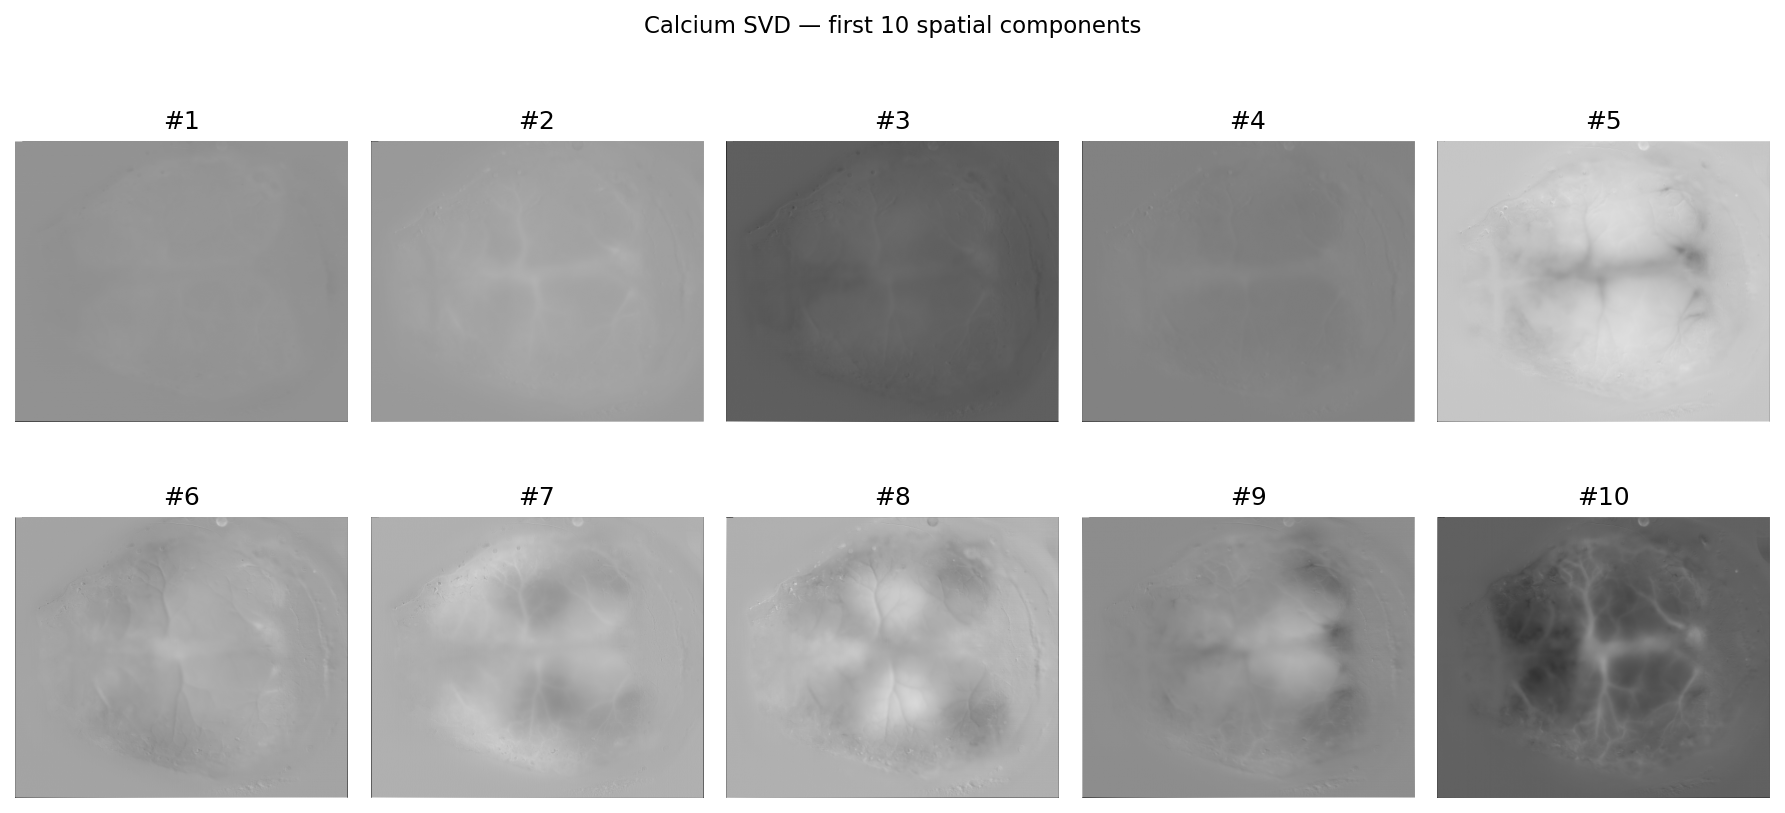

In [7]:
ps_calcium = image_segmentation["SVDTemporalComponentsCalcium"]
U_calcium  = ps_calcium["image_mask"].data[:]  # shape: (n_components, height, width)

print(f"U_calcium shape : {U_calcium.shape}  → (n_components, height, width)")

roi_ids = range(10)
fig, axes = plt.subplots(2, 5, sharex=True, sharey=True, dpi=150)
for ax, roi_id in zip(axes.flatten(), roi_ids):
    ax.imshow(U_calcium[roi_id], cmap="gray")
    ax.set_title(f"#{roi_id + 1}")
    ax.axis("off")
plt.suptitle("Calcium SVD — first 10 spatial components", fontsize=11)
plt.tight_layout()
plt.show()

### Temporal Components (SVT) <a id="temporal"></a>

Temporal SVD coefficients are stored as `RoiResponseSeries` inside the
`Fluorescence` container named `SVDTemporalComponents`.

| Series name | Description |
|---|---|
| `HaemoCorrectedSVDTemporalComponentsCalcium` | Haemodynamic-corrected calcium SVT |
| `DenoisedSVDTemporalComponentsCalcium` | Uncorrected (raw) calcium SVT |
| `DenoisedSVDTemporalComponentsIsosbestic` | Isosbestic (405 nm) SVT |

In [8]:
svd_module = ophys["SVDTemporalComponents"]

print("=== SVD Temporal Components ===")
print("-" * 100)
for _, series in svd_module.roi_response_series.items():
    print(f"Trace: {series.name}")
    print("-" * 100)
    print(f"   Description   : {series.description}")
    print(f"   Number of ROIs: {series.data.shape[1]}")
    print(f"   Duration      : {series.timestamps[-1] - series.timestamps[0]:.2f} seconds")
    print("-" * 100)

=== SVD Temporal Components ===
----------------------------------------------------------------------------------------------------
Trace: DenoisedSVDTemporalComponentsCalcium
----------------------------------------------------------------------------------------------------
   Description   : SVD temporal components (denoised/decomposed) of widefield calcium imaging from Blue light (470 nm) excitation.
   Number of ROIs: 200
   Duration      : 4920.59 seconds
----------------------------------------------------------------------------------------------------
Trace: DenoisedSVDTemporalComponentsIsosbestic
----------------------------------------------------------------------------------------------------
   Description   : SVD temporal components (denoised/decomposed) of widefield calcium imaging from Violet light (405 nm) excitation.
   Number of ROIs: 200
   Duration      : 4920.59 seconds
---------------------------------------------------------------------------------------------

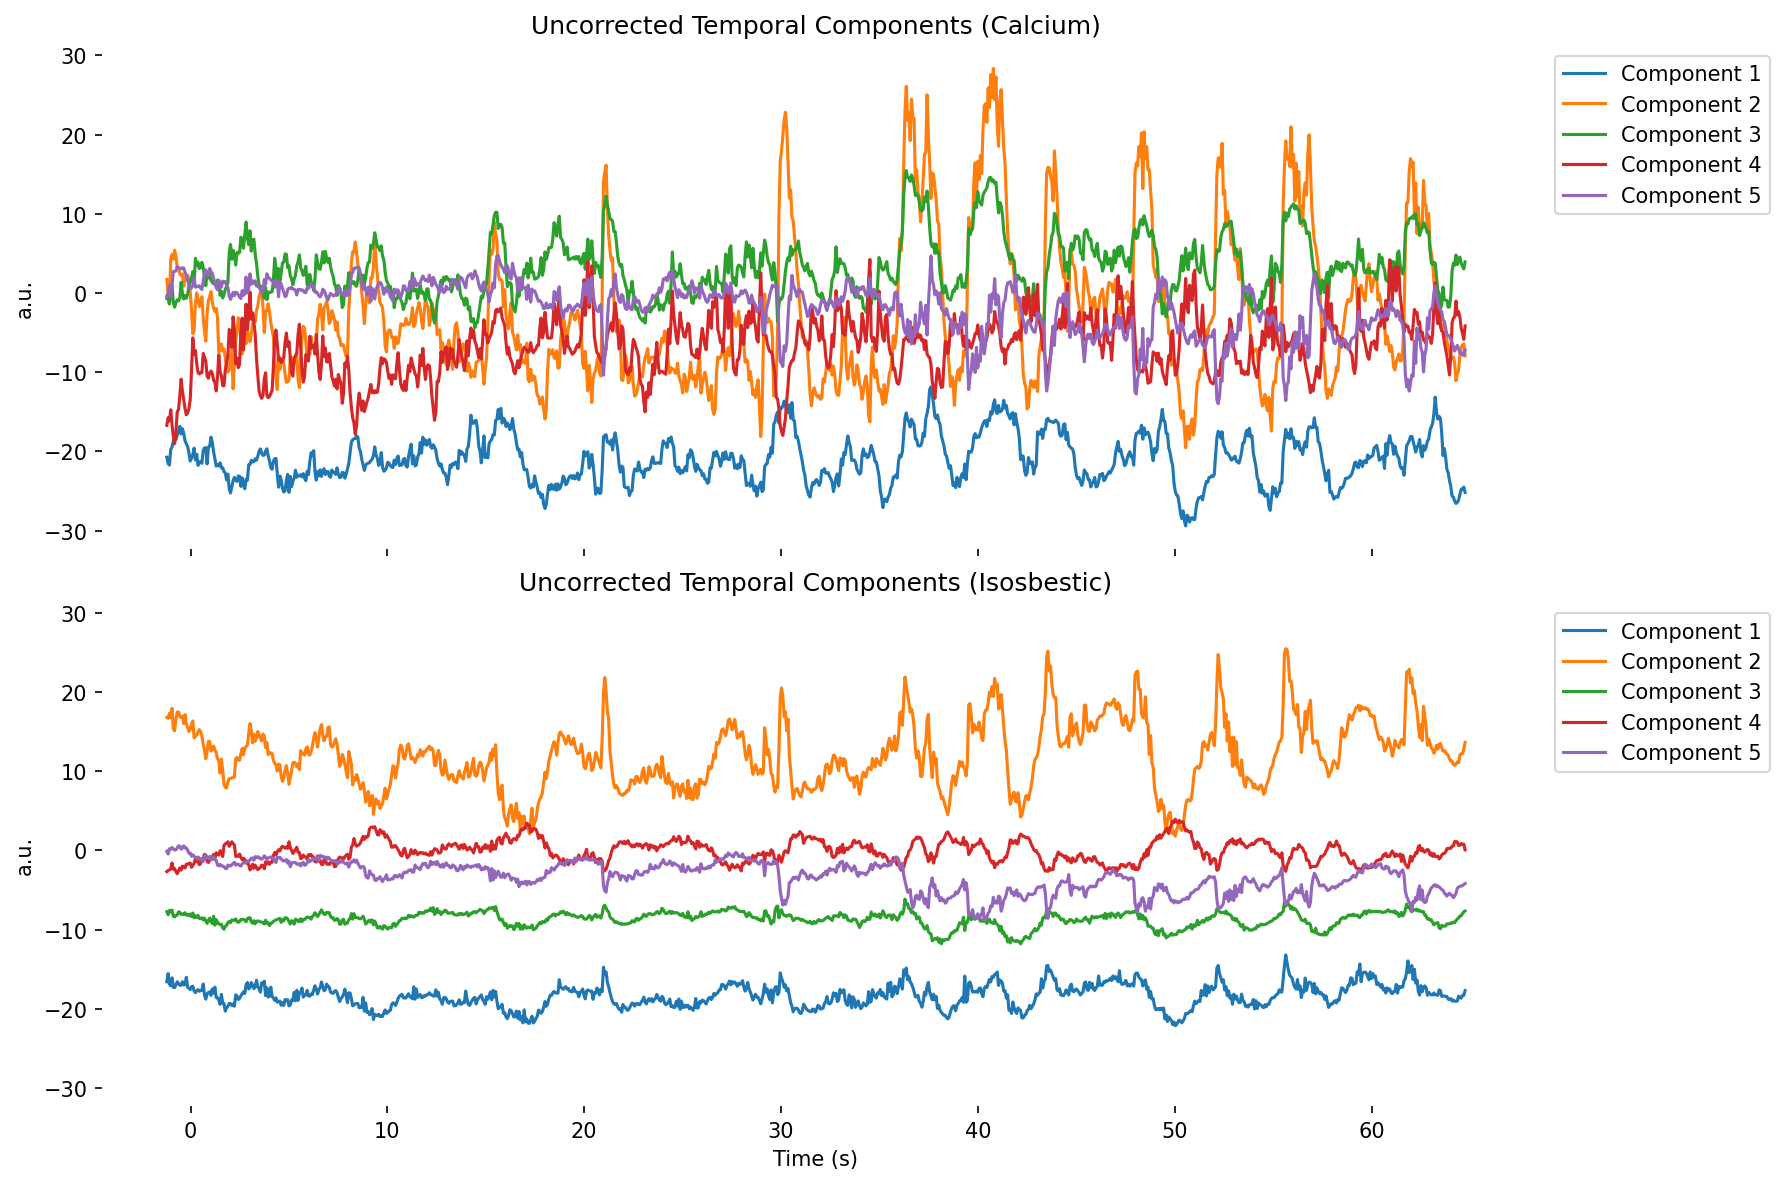

In [9]:
num_rois = 5

fig, ax = plt.subplots(2, 1, figsize=(12, 8), dpi=150, sharex=True, sharey=True)

roi_response     = svd_module["DenoisedSVDTemporalComponentsCalcium"]
roi_response_iso = svd_module["DenoisedSVDTemporalComponentsIsosbestic"]
time = roi_response.timestamps[:1000]

for roi_idx in range(num_rois):
    ax[0].plot(time, roi_response.data[:1000, roi_idx], label=f"Component {roi_idx + 1}")
ax[0].set_title("Uncorrected Temporal Components (Calcium)")
ax[0].set_ylabel("a.u.")
ax[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax[0].set_frame_on(False)

for roi_idx in range(num_rois):
    ax[1].plot(time, roi_response_iso.data[:1000, roi_idx], label=f"Component {roi_idx + 1}")
ax[1].set_title("Uncorrected Temporal Components (Isosbestic)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("a.u.")
ax[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax[1].set_frame_on(False)

plt.tight_layout()
plt.show()

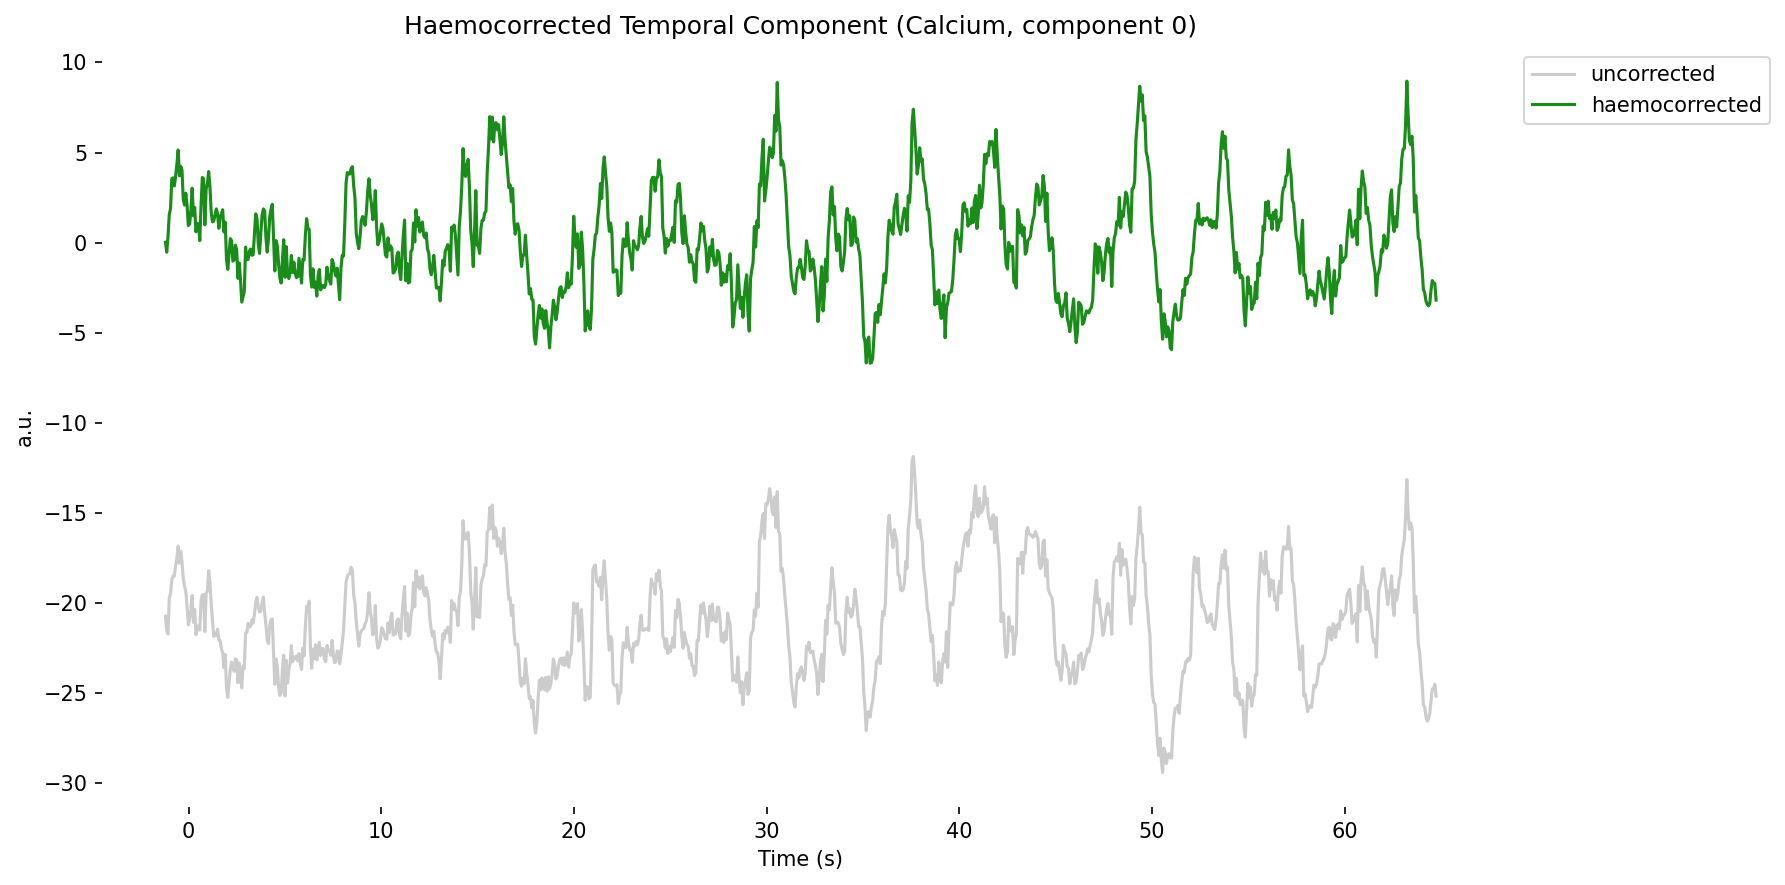

In [10]:
roi_response_dff = svd_module["HaemoCorrectedSVDTemporalComponentsCalcium"]
roi_response_raw = svd_module["DenoisedSVDTemporalComponentsCalcium"]

time = roi_response_raw.timestamps[:1000]

fig, ax = plt.subplots(dpi=150)
ax.plot(time, roi_response_raw.data[:1000, 0], label="uncorrected", color="grey", alpha=0.4)
ax.plot(time, roi_response_dff.data[:1000, 0], label="haemocorrected", color="green", alpha=0.9)
ax.set_title("Haemocorrected Temporal Component (Calcium, component 0)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("a.u.")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_frame_on(False)
plt.tight_layout()
plt.show()

### Reconstructing full-frame ΔF/F: 


In [ ]:
import numpy as np
import wfield

# Spatial components (U):
# plane_segmentation["image_mask"].data has shape: (n_components, height, width)
U = nwbfile.processing["ophys"]["SVDSpatialComponents"]["SVDTemporalComponentsCalcium"].image_mask[:]
print(f"Spatial components U shape (n_components, height, width): {U.shape}")

# Haemocorrected temporal components (SVT):
# roi_response_dff.data has shape: (time, n_components)
SVT = nwbfile.processing["ophys"]["SVDTemporalComponents"]["HaemoCorrectedSVDTemporalComponentsCalcium"].data[:]
print(f"Temporal components SVT shape (time, n_components): {SVT.shape}")

# --- Prepare shapes for SVDStack ---

# wfield.SVDStack expects:
#   U_stack:  (height, width, n_components)
#   SVT_stack: (n_components, time)
U_stack = np.transpose(U, (1, 2, 0))  # (height, width, n_components)
SVT_stack = SVT.T  # (n_components, time)

print(f"U_stack shape (height, width, n_components): {U_stack.shape}")
print(f"SVT_stack shape (n_components, time):         {SVT_stack.shape}")

# --- Build the reconstructed imaging stack ---
# Resulting stack has shape: (time, height, width)
stack = wfield.SVDStack(U_stack, SVT_stack)
print(f"Reconstructed stack shape (time, height, width): {stack.shape}")

Spatial components U shape (n_components, height, width): (200, 540, 640)
Temporal components SVT shape (time, n_components): (74531, 200)
U_stack shape (height, width, n_components): (540, 640, 200)
SVT_stack shape (n_components, time):         (200, 74531)
Reconstructed stack shape (time, height, width): [74531, 540, 640]


### Aligning data to the Allen reference atlas

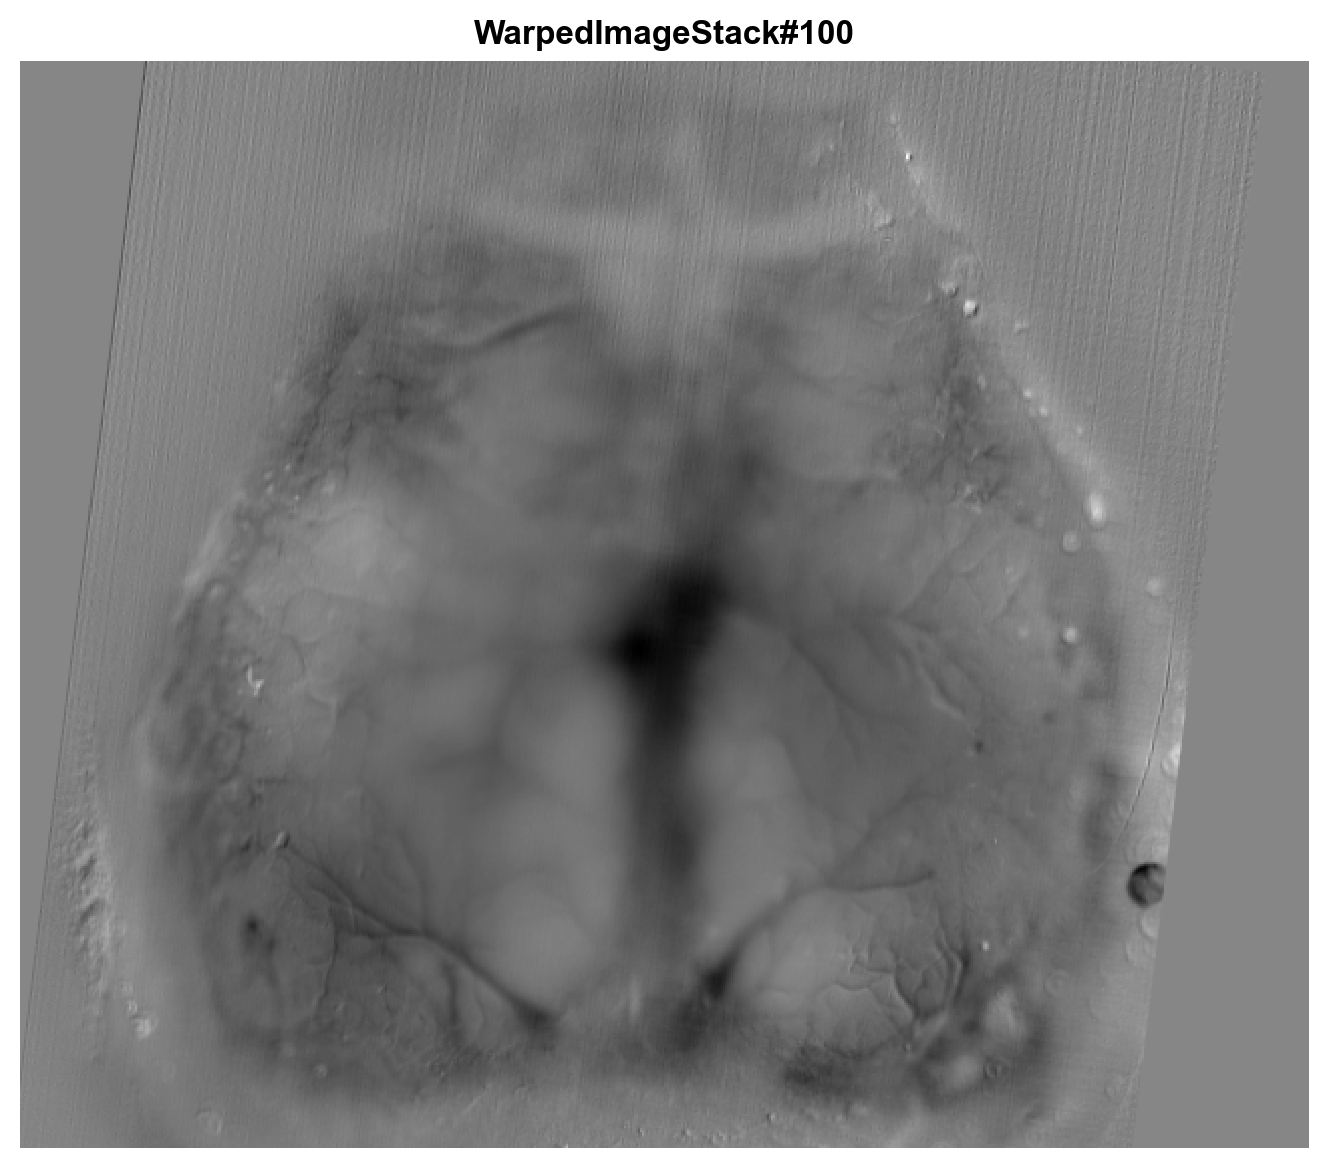

In [12]:
from skimage.transform import SimilarityTransform

atlas_registration = nwbfile.lab_meta_data["atlas_registration"]
affine_transform = atlas_registration.affine_transformation
M = SimilarityTransform(affine_transform.affine_matrix)
stack.set_warped(True, M=M)
frame_ind = 100
fig, ax = plt.subplots(1,1, dpi=200)
ax.imshow(stack[frame_ind], cmap="gray")
ax.set_title(f"WarpedImageStack#{frame_ind}", fontsize=12)
ax.axis("off")

plt.tight_layout()
plt.show()

### Extract Brain Region Activity

Now that `stack` is warped into registered (atlas) space, it lives in the same
coordinate frame as `AnatomicalCoordinatesImageCCFv3` — the per-pixel Allen
acronym map in registered space. We can therefore build a boolean mask for
**any brain region** directly from that map and apply it to the reconstructed,
aligned frames of `stack` to get a per-region activity trace.

In [ ]:
import ndx_anatomical_localization  # noqa: F401 — register custom NWB types

# --- Per-pixel Allen acronym map (registered space) ---
localization = nwbfile.lab_meta_data["localization"]
aci_reg = localization.anatomical_coordinates_images["AnatomicalCoordinatesImageCCFv3"]
region_names = np.asarray(aci_reg.brain_region[:])  # (H, W) Allen acronym per registered pixel

unique_regions = np.unique(region_names)
unique_regions = unique_regions[unique_regions != "out-of-atlas"]
print(f"Found {len(unique_regions)} brain regions in atlas")

# --- Reconstruct a short window of warped frames from the stack ---
window_seconds = 30
svt_times = SVT.timestamps[:]
frame_indexes = (svt_times >= svt_times[0]) & (svt_times <= svt_times[0] + window_seconds)
t = svt_times[frame_indexes]

# stack[t] returns a frame already warped to registered space (set_warped(True, M=M))
frames = stack[frame_indexes]
print(f"Reconstructed warped frames, shape {frames.shape}")

# --- Mean over each region mask → one trace per region ---
region_traces = {
    region: frames[:, region_names == region].mean(axis=1)
    for region in unique_regions
    if (region_names == region).any()
}
print(f"Computed traces for {len(region_traces)} regions (window= {window_seconds} sec)")

Found 33 brain regions in atlas
Reconstructed warped frames, shape (455, 540, 640)
Computed traces for 33 regions (window= 30 sec)


Plotting: ['VISp', 'VISa', 'RSPd', 'SSp-bfd', 'MOp', 'MOs']


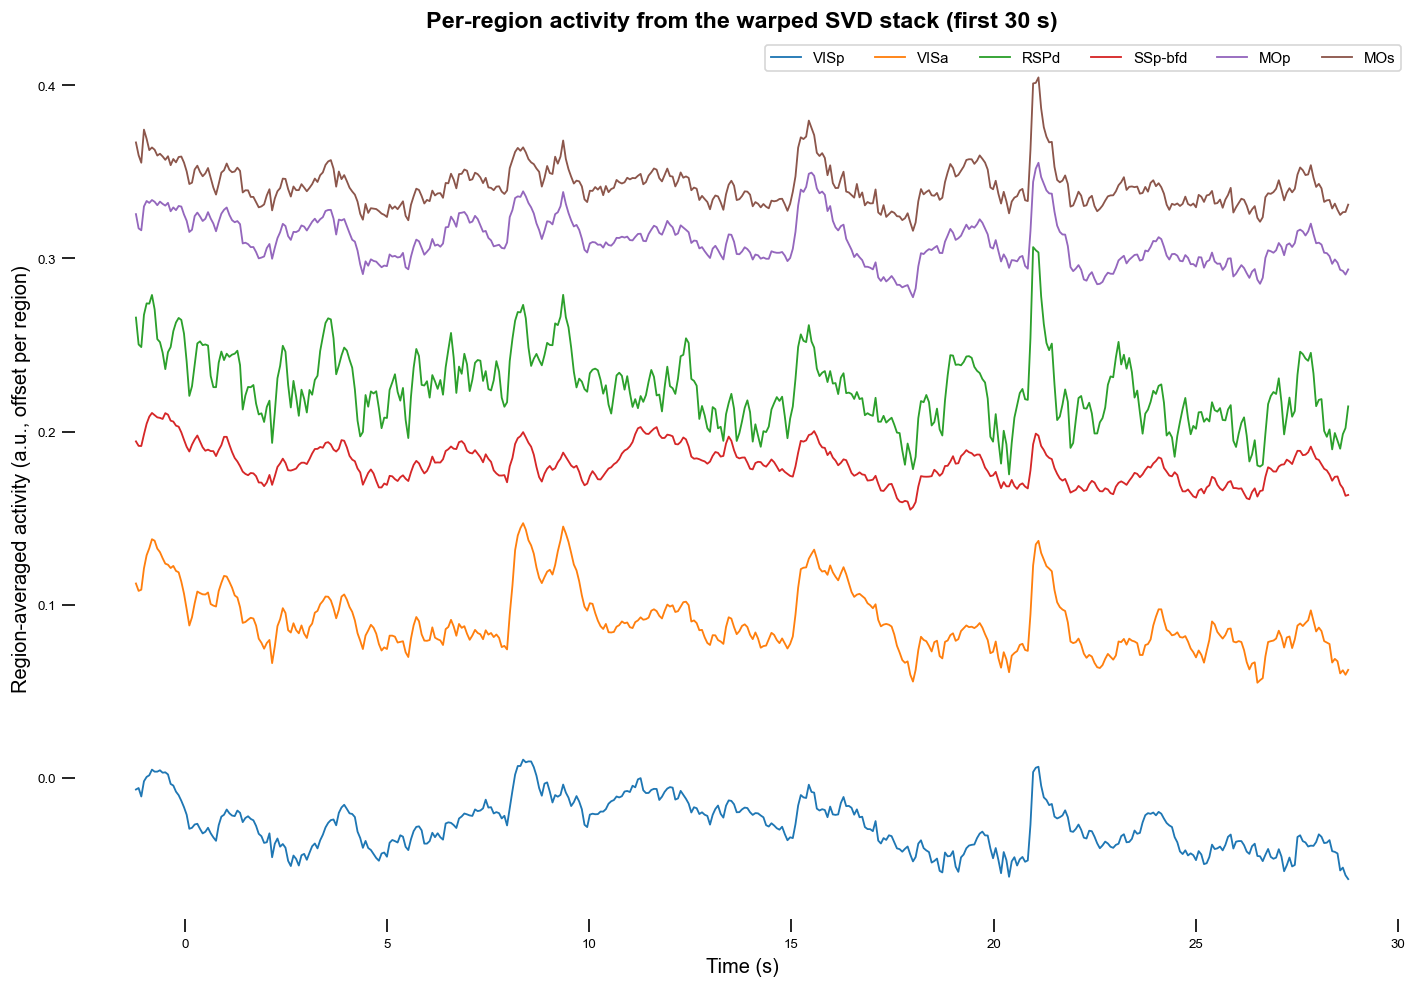

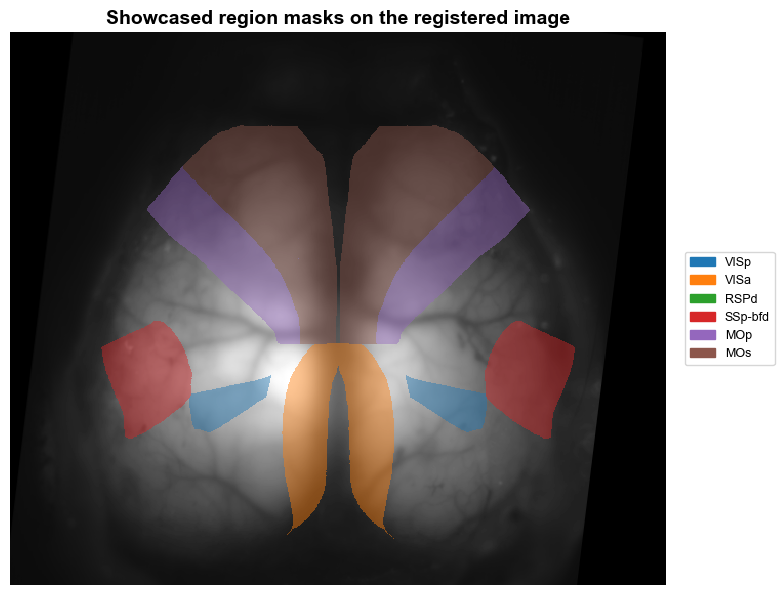

In [16]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# --- Pick a few representative regions; skip any missing from this session ---
showcase = ["VISp", "VISa", "RSPd", "SSp-bfd", "MOp", "MOs"]
showcase = [r for r in showcase if r in region_traces]
print(f"Plotting: {showcase}")

# --- Plot region-averaged traces, offset vertically ---
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(12, 1.4 * max(len(showcase), 1)), dpi=120)
for i, region in enumerate(showcase):
    trace = region_traces[region]
    offset = i * 6 * np.std(trace)
    ax.plot(t, trace + offset, color=cmap(i), lw=1.1, label=region)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Region-averaged activity (a.u., offset per region)")
ax.set_title(f"Per-region activity from the warped SVD stack (first {window_seconds} s)")
ax.legend(loc="upper right", fontsize=9, ncol=len(showcase))
ax.set_frame_on(False)
plt.tight_layout()
plt.show()

# --- Overlay the showcased masks on the registered image ---
registered_img = atlas_registration.registered_image.data[:]
showcase_to_idx = {r: i + 1 for i, r in enumerate(showcase)}
idx_img = np.zeros(region_names.shape, dtype=np.int16)
for r, i in showcase_to_idx.items():
    idx_img[region_names == r] = i
idx_masked = np.ma.masked_where(idx_img == 0, idx_img)

colors = np.vstack([[0, 0, 0, 0], cmap(np.arange(len(showcase)))])
region_cmap = ListedColormap(colors)
region_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(8, 7), dpi=100)
ax.imshow(registered_img, cmap="gray")
ax.imshow(idx_masked, cmap=region_cmap, alpha=0.45, interpolation="nearest")
handles = [mpatches.Patch(color=cmap(i), label=r) for i, r in enumerate(showcase)]
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.set_title("Showcased region masks on the registered image")
ax.axis("off")
plt.tight_layout()
plt.show()

### Summary Images <a id="summary-images"></a>

Mean fluorescence images and registration images are all stored as `GrayscaleImage`
objects in `ophys["Images"]`.

| Image name | Description |
|---|---|
| `MeanImage` | Mean frame under 470 nm (calcium) excitation |
| `MeanImageIsosbestic` | Mean frame under 405 nm (isosbestic) excitation |
| `RegisteredImage` | FOV after affine warp to atlas space |
| `AtlasProjectionImage` | 2-D Allen CCF dorsal-cortex reference |

In [ ]:
summary_images = ophys["Images"]

print("=== Images container ===")
print("-" * 100)
for name, img in summary_images.images.items():
    print(f"Image: {name}")
    print("-" * 100)
    print(f"   Description: {img.description}")
    print(f"   Dimensions : {img.data[:].shape}")
    print("-" * 100)

=== Images container ===
----------------------------------------------------------------------------------------------------
Image: AtlasProjectionImage
----------------------------------------------------------------------------------------------------
   Description: The 2D reference projection image from Allen CCF dorsal cortex.
   Dimensions : (1320, 1140)
----------------------------------------------------------------------------------------------------
Image: MeanImage
----------------------------------------------------------------------------------------------------
   Description: The mean image under Blue (470 nm) excitation across the imaging session. The dimensions are (height, width).
   Dimensions : (540, 640)
----------------------------------------------------------------------------------------------------
Image: MeanImageIsosbestic
----------------------------------------------------------------------------------------------------
   Description: The mean image unde

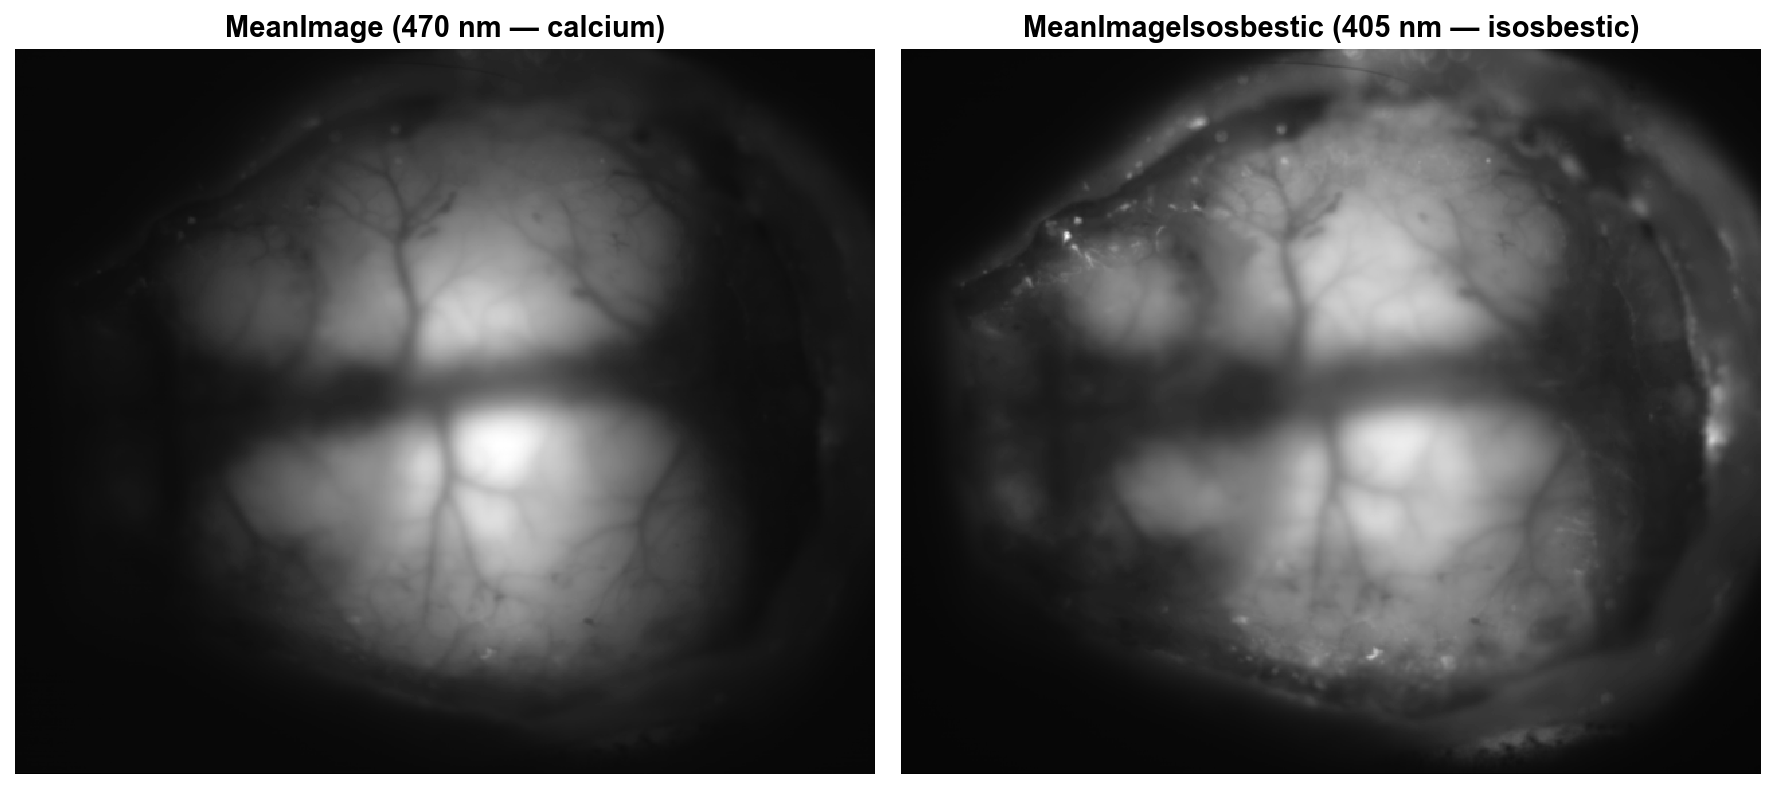

In [ ]:
mean_ca  = summary_images.images["MeanImage"]
mean_iso = summary_images.images["MeanImageIsosbestic"]

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, dpi=150)
axes[0].imshow(mean_ca.data[:],  cmap="gray")
axes[0].set_title("MeanImage (470 nm — calcium)")
axes[0].axis("off")
axes[1].imshow(mean_iso.data[:], cmap="gray")
axes[1].set_title("MeanImageIsosbestic (405 nm — isosbestic)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

---

## 4. Behavior <a id="behavior"></a>

### Epochs <a id="epochs"></a>

In [ ]:
print("Available processing modules:", list(nwbfile.processing.keys()))
print()
print("Note: lick_times, pupil, motion_energy, and pose_estimation are only")
print("present for sessions where IBL behavioral processing was run.")

Available processing modules: ['motion_energy', 'ophys', 'passive_protocol', 'pose_estimation', 'wheel']

Note: lick_times, pupil, motion_energy, and pose_estimation are only
present for sessions where IBL behavioral processing was run.


In [ ]:
nwbfile.epochs

,start_time,stop_time,protocol_type,epoch_description
id,,,,
0,0.000000,3769.991275,task,Active behavioral task period. The mouse performs a decision-making task where it must turn a wheel to move a visual stimulus (Gabor patch) to the center of the screen. Correct responses are rewarded with water; incorrect responses trigger white noise feedback. The trials table contains detailed timing and outcome data for each trial during this epoch.
1,3769.991275,4918.060357,passive,"Passive stimulus replay period. Visual and auditory stimuli are presented while the mouse is head-fixed but not performing any task. This epoch includes: (1) replay of task-relevant stimuli (Gabor patches at various contrasts and positions), (2) sparse noise stimuli for receptive field mapping, and (3) natural movie clips. Used for characterizing sensory responses independent of task engagement."


### Trials <a id="trials"></a>

In [ ]:
trials_df = nwbfile.trials[:]
trials_df.head()

,start_time,stop_time,quiescence_period,gabor_stimulus_onset_time,auditory_cue_time,wheel_movement_onset_time,choice_registration_time,feedback_time,gabor_stimulus_offset_time,gabor_stimulus_contrast,gabor_stimulus_side,mouse_wheel_choice,is_mouse_rewarded,reward_volume_uL,probability_left,block_type,block_index
id,,,,,,,,,,,,,,,,,
0,34.471859,38.257521,0.691901,NaN,NaN,NaN,36.201441,NaN,NaN,25.00,left,clockwise,True,1.5,0.5,unbiased,0
1,38.659915,41.757385,0.546522,39.271533,39.272477,39.430643,39.697605,39.697749,41.257331,25.00,left,clockwise,True,1.5,0.5,unbiased,0
2,42.148278,46.671291,0.435289,42.637931,42.639064,43.372643,43.615982,43.617048,46.171323,6.25,right,clockwise,False,0.0,0.5,unbiased,0
3,47.078790,50.057393,0.645150,47.790850,47.791699,47.892643,47.997291,47.997397,49.557357,100.00,left,clockwise,True,1.5,0.5,unbiased,0
4,50.477190,54.271119,0.693158,51.904518,51.905274,52.073643,52.194202,52.194326,53.770995,25.00,right,counter_clockwise,True,1.5,0.5,unbiased,0


### Lick Times <a id="lick-times"></a>

Lick events detected from video-based tongue pose estimation are stored as an `Events` object
in the `lick_times` processing module.

```python
lick_events = nwbfile.processing["lick_times"]["EventsLickTimes"]
timestamps  = lick_events.timestamps[:]
```

In [ ]:
if "lick_times" not in nwbfile.processing:
    print("lick_times module not available for this session — skipping.")
else:
    lick_events = nwbfile.processing["lick_times"]["EventsLickTimes"]

    print("=== LICK TIMES ===")
    print(f"Description: {lick_events.description}\n")
    lick_times = lick_events.timestamps[:]
    print(f"Number of licks     : {len(lick_times)}")
    print(f"Session duration    : {lick_times[-1] - lick_times[0]:.2f} s")
    print(f"Mean lick rate      : {len(lick_times) / (lick_times[-1] - lick_times[0]):.2f} licks/s")

lick_times module not available for this session — skipping.


In [ ]:
if "lick_times" in nwbfile.processing:
    # Lick raster over a 2-minute window
    window_start = lick_times[0]
    window_end   = lick_times[0] + 120.0
    lick_window  = lick_times[(lick_times >= window_start) & (lick_times <= window_end)]

    fig, ax = plt.subplots(figsize=(8, 2), dpi=150)
    ax.vlines(lick_window, 0, 1, linewidth=0.6, color="steelblue", alpha=0.8)
    ax.set_xlim(window_start, window_end)
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title("Lick Events (first 2 minutes)")
    ax.set_frame_on(False)
    plt.tight_layout()
    plt.show()

In [ ]:
if "lick_times" in nwbfile.processing:
    # Trial-aligned lick raster + PSTH around feedback time
    pre_time  = 0.5    # s before feedback
    post_time = 2.0    # s after feedback
    bin_size  = 0.05   # 50 ms bins

    feedback_times = nwbfile.trials["feedback_time"][:]
    is_rewarded    = nwbfile.trials["is_mouse_rewarded"][:]

    bins        = np.arange(-pre_time, post_time + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2

    raster_rewarded, raster_unrewarded = [], []
    psth_rewarded   = np.zeros(len(bins) - 1)
    psth_unrewarded = np.zeros(len(bins) - 1)

    for t_fb, rewarded in zip(feedback_times, is_rewarded):
        rel    = lick_times[(lick_times >= t_fb - pre_time) & (lick_times <= t_fb + post_time)] - t_fb
        counts, _ = np.histogram(rel, bins=bins)
        if rewarded:
            raster_rewarded.append(rel)
            psth_rewarded += counts
        else:
            raster_unrewarded.append(rel)
            psth_unrewarded += counts

    n_rew   = max(len(raster_rewarded),   1)
    n_unrew = max(len(raster_unrewarded), 1)
    psth_rewarded   /= n_rew   * bin_size
    psth_unrewarded /= n_unrew * bin_size

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150, sharex=True)

    for col, (raster, psth, label, color) in enumerate([
        (raster_rewarded,   psth_rewarded,   "Rewarded",   "green"),
        (raster_unrewarded, psth_unrewarded, "Unrewarded", "gray"),
    ]):
        for trial_idx, trial_lick_times in enumerate(raster):
            axes[0, col].vlines(trial_lick_times, trial_idx - 0.4, trial_idx + 0.4,
                                linewidth=2, color=color, alpha=0.7)
        axes[0, col].axvline(0, color="black", linewidth=1, linestyle="--", label="Feedback")
        axes[0, col].set_ylabel("Trial")
        axes[0, col].set_title(f"{label} trials (n={len(raster)})")
        axes[0, col].legend(loc="upper right", fontsize=8)
        axes[0, col].set_frame_on(False)

        axes[1, col].bar(bin_centers, psth, width=bin_size, color=color, alpha=0.7, edgecolor="none")
        axes[1, col].axvline(0, color="black", linewidth=1, linestyle="--")
        axes[1, col].set_xlabel("Time from feedback (s)")
        axes[1, col].set_ylabel("Lick rate (Hz)")
        axes[1, col].set_frame_on(False)

    fig.suptitle("Lick Raster and PSTH Aligned to Feedback", fontsize=12)
    plt.tight_layout()
    plt.show()

### Pupil <a id="pupil"></a>

Pupil diameter measurements from video-based eye tracking are stored as `TimeSeries`
in the `pupil` processing module.

| Series name | Content |
|---|---|
| `LeftPupilDiameter` | Raw left-camera pupil diameter |
| `LeftPupilDiameterSmoothed` | Temporally smoothed left-camera diameter |
| `RightPupilDiameter` | Raw right-camera pupil diameter |
| `RightPupilDiameterSmoothed` | Temporally smoothed right-camera diameter |

In [ ]:
if "pupil" not in nwbfile.processing:
    print("pupil module not available for this session — skipping.")
else:
    pupil_module = nwbfile.processing["pupil"]

    print("=== PUPIL PROCESSING MODULE ===")
    print("-" * 80)
    for name, ts in pupil_module.data_interfaces.items():
        print(f"  {name}")
        print(f"    Description: {ts.description}")
        print(f"    Samples    : {ts.data.shape[0]}  |  Unit: {ts.unit}")
        print("-" * 80)

pupil module not available for this session — skipping.


In [ ]:
if "pupil" in nwbfile.processing:
    raw_series = {name: ts for name, ts in pupil_module.data_interfaces.items()
                  if "Smoothed" not in name}

    fig, axes = plt.subplots(len(raw_series), 1,
                             figsize=(12, 3 * len(raw_series)), dpi=150, squeeze=False)

    for ax, (name, raw_ts) in zip(axes[:, 0], raw_series.items()):
        t = raw_ts.timestamps[:]
        window_mask = (t >= t[0]) & (t <= t[0] + 120.0)
        ax.plot(t[window_mask], raw_ts.data[window_mask], color="blue", linewidth=0.8)
        ax.set_title(f"{name} (first 2 minutes)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(f"Diameter ({raw_ts.unit})")
        ax.set_frame_on(False)

    plt.tight_layout()
    plt.show()

### ROI Motion Energy <a id="motion-energy"></a>

In [ ]:
if "motion_energy" not in nwbfile.processing:
    print("motion_energy module not available for this session — skipping.")
else:
    print("=== MOTION ENERGY PROCESSING MODULE ===\n")
    for name, proc in nwbfile.processing["motion_energy"].items():
        print("-" * 100)
        print(f"{name} - {proc.description}")

=== MOTION ENERGY PROCESSING MODULE ===

----------------------------------------------------------------------------------------------------
BodyCameraMotionEnergy - Motion energy calculated for a region of the body camera video. ROI dimensions: 201 pixels wide, 210 pixels tall, top-left corner at (134, 127).

Calculation: For each frame, pixel intensity differences are computed between frame N and frame N+2 (default offset). The Euclidean norm (L2) of differences is summed across all ROI pixels, then min-max normalized to [0, 1] range. Higher values indicate more movement within the ROI.

CAUTION: Video loading libraries may use different axis conventions. When loading with cv2 in Python, x and y axes are flipped. The region then becomes [127:337, 134:335].
----------------------------------------------------------------------------------------------------
LeftCameraMotionEnergy - Motion energy calculated for a region of the left camera video. ROI dimensions: 174 pixels wide, 116 pix

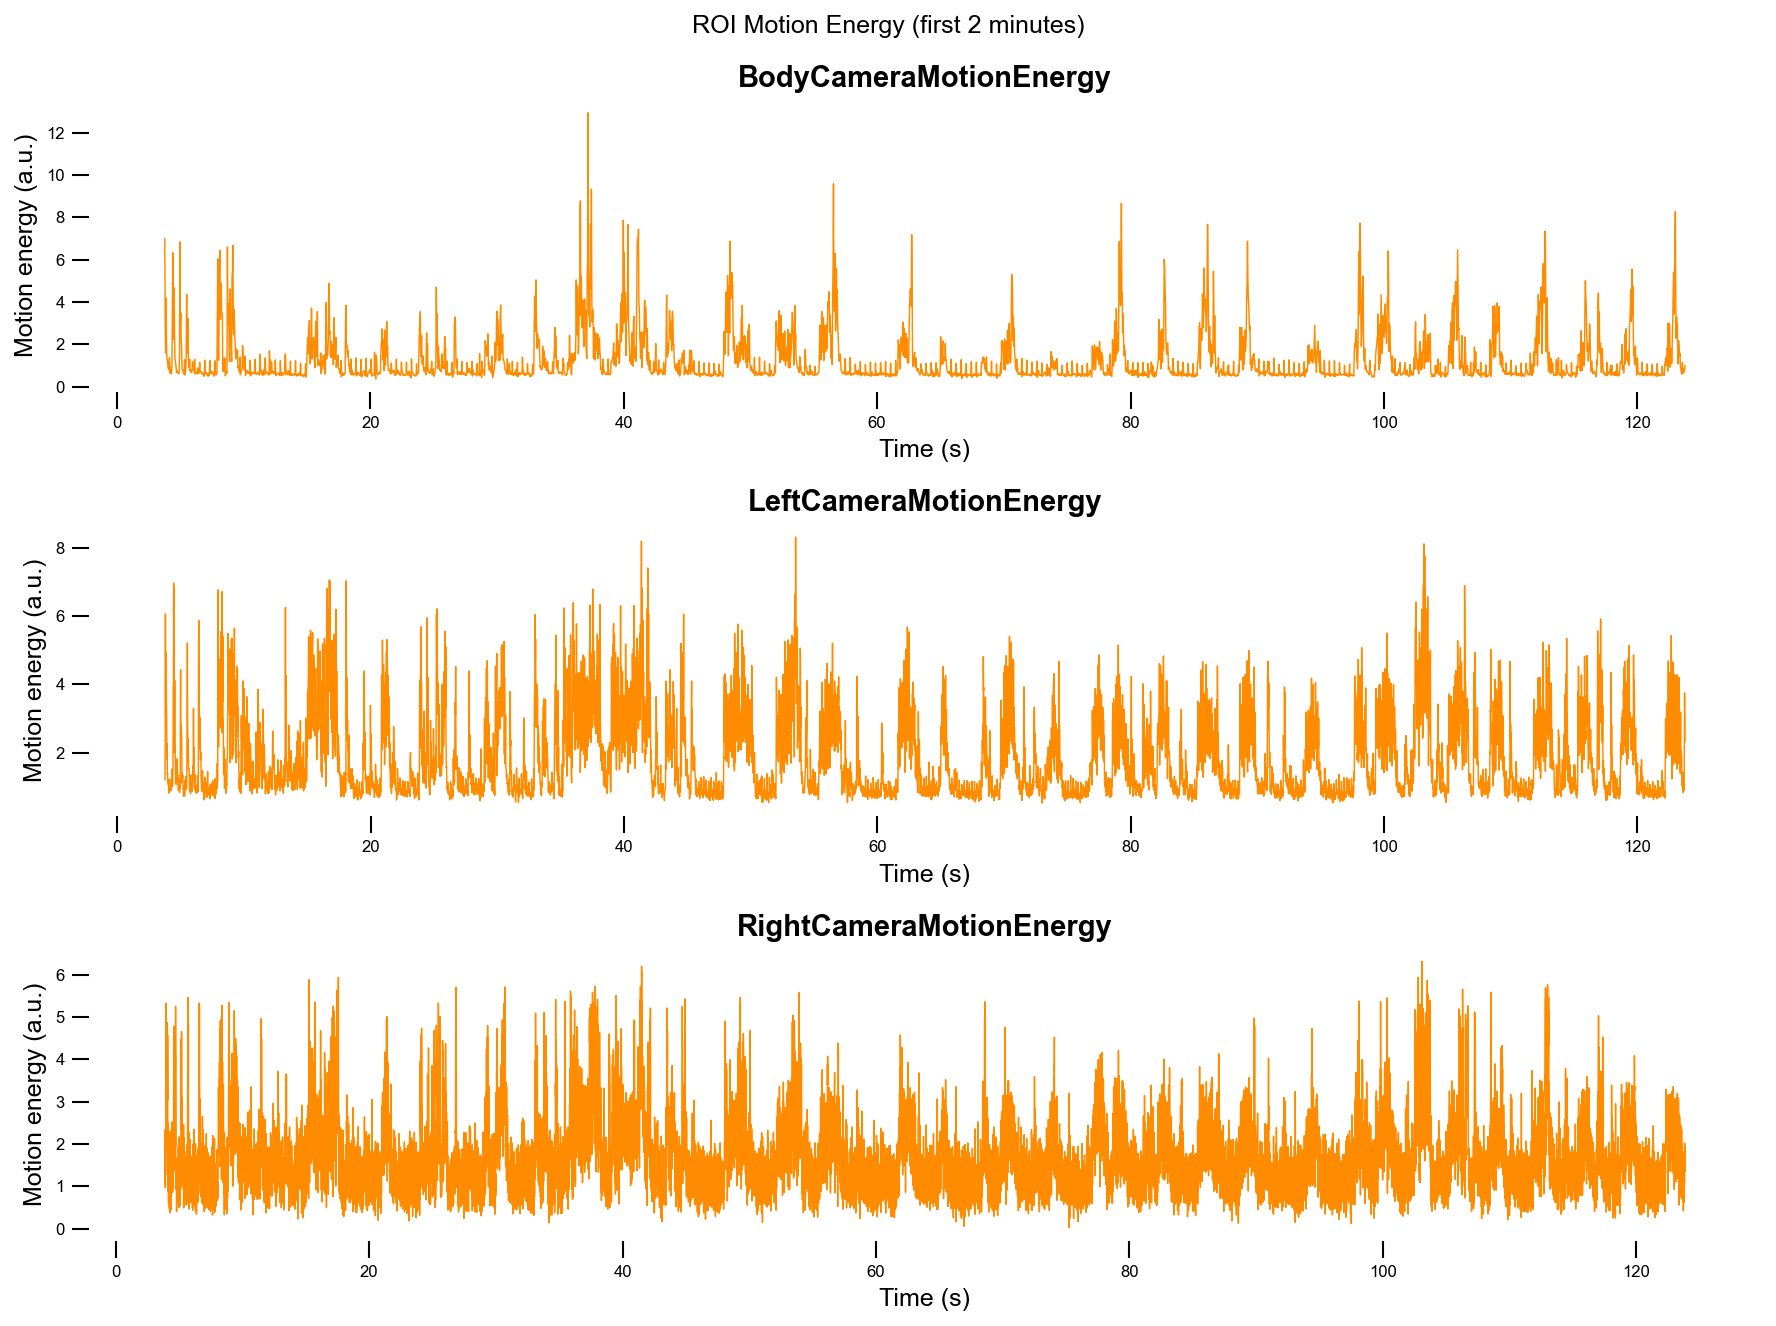

In [ ]:
if "motion_energy" in nwbfile.processing:
    motion_energy_module = nwbfile.processing["motion_energy"]
    me_names = list(motion_energy_module.data_interfaces.keys())

    fig, axes = plt.subplots(len(me_names), 1,
                             figsize=(12, 3 * len(me_names)), dpi=150, squeeze=False, sharex=False)

    for ax, name in zip(axes[:, 0], me_names):
        ts = motion_energy_module[name]
        t  = ts.timestamps[:]
        window_mask = (t >= t[0]) & (t <= t[0] + 120.0)
        ax.plot(t[window_mask], ts.data[window_mask], color="darkorange", linewidth=0.7)
        ax.set_title(name)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Motion energy (a.u.)")
        ax.set_frame_on(False)

    plt.suptitle("ROI Motion Energy (first 2 minutes)", fontsize=12)
    plt.tight_layout()
    plt.show()

### Wheel <a id="wheel"></a>

In [ ]:
print("=== WHEEL PROCESSING MODULE ===\n")
for name, proc in nwbfile.processing["wheel"].items():
    print("-" * 100)
    if hasattr(proc, "spatial_series"):
        print(f"{name}:")
        for ss_name, ss in proc.spatial_series.items():
            print(f"\t{ss_name} - {ss.description}")
    elif hasattr(proc, "to_dataframe"):
        print(f"{name} - {proc.description}")
        print(proc.to_dataframe().head(5).to_string())
    else:
        print(f"{name} - {proc.description}")

=== WHEEL PROCESSING MODULE ===

----------------------------------------------------------------------------------------------------
WheelAccelerationSmoothed - Wheel angular acceleration derived from velocity (WheelVelocitySmoothed). Computed as the second derivative of the smoothed position signal.
----------------------------------------------------------------------------------------------------
WheelPosition - Absolute unwrapped wheel angle recorded from a quadrature rotary encoder. The wheel (diameter 6.2 cm) is positioned under the mouse's forepaws and serves as the primary behavioral input device for reporting perceptual decisions. Sampling is event-driven: timestamps are recorded only when the wheel moves (i.e., when the encoder generates TTL edges), resulting in irregular inter-sample intervals. The encoder uses X4 decoding of two 90-degree phase-shifted channels, providing 4096 effective counts per revolution (angular resolution ~0.088 degrees or 2*pi/4096 radians). Positio

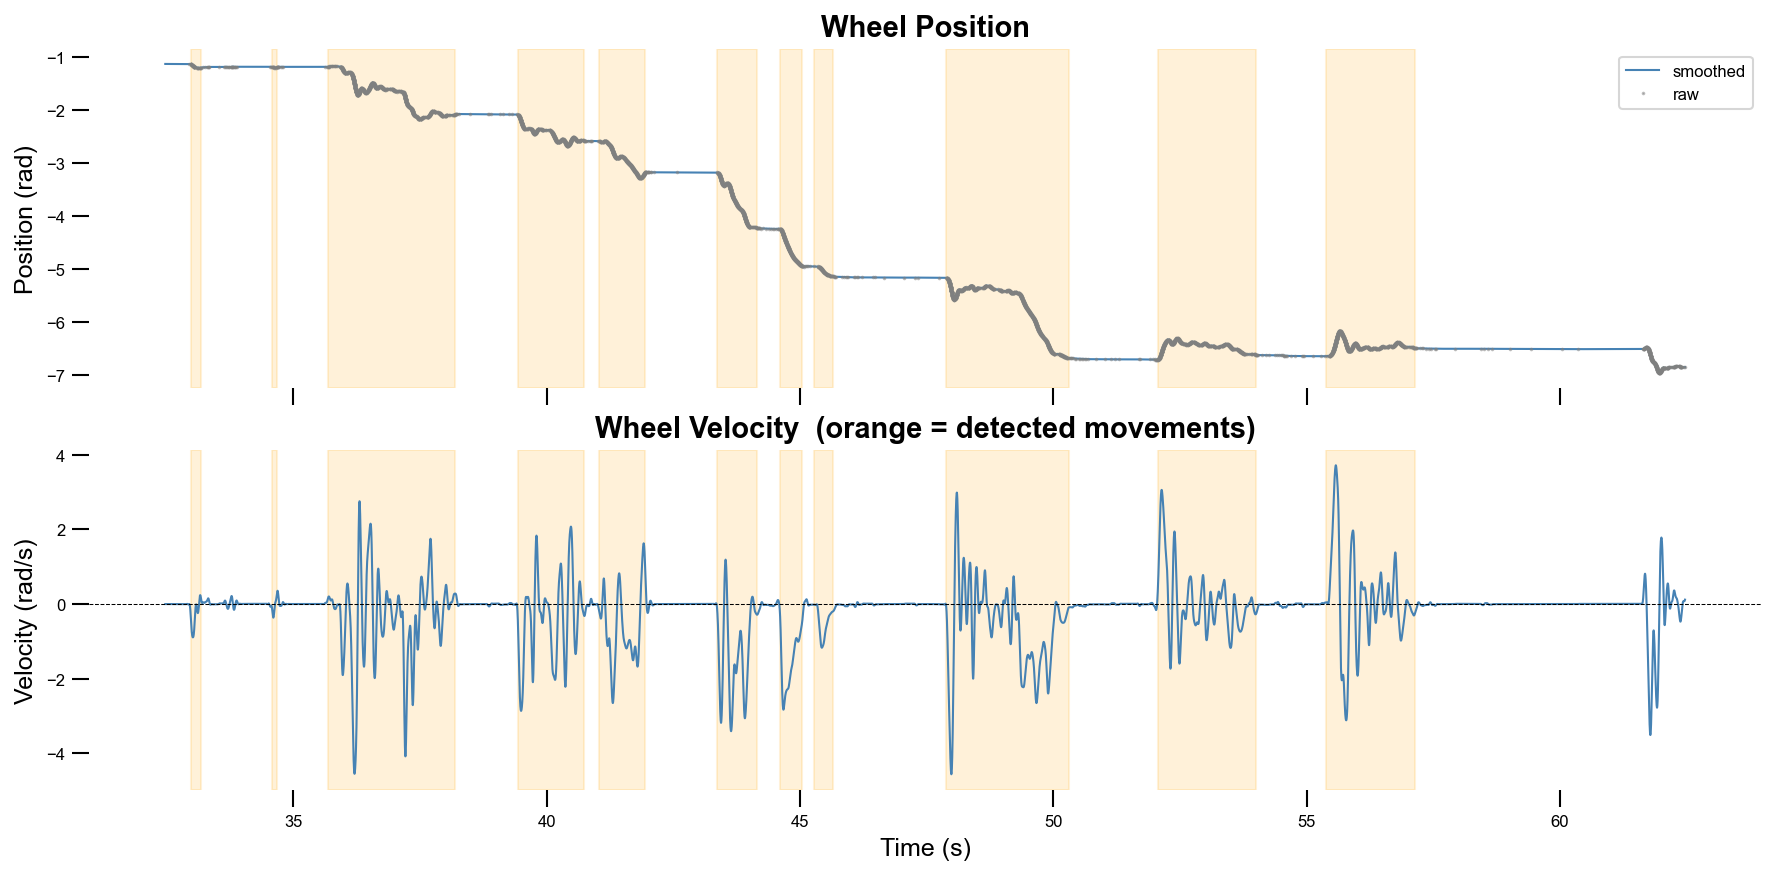

In [ ]:
wheel_module = nwbfile.processing["wheel"]

pos_smooth = wheel_module["WheelPositionSmoothed"]
vel_smooth = wheel_module["WheelVelocitySmoothed"]
movements  = wheel_module["WheelMovementIntervals"]
pos_raw    = wheel_module["WheelPosition"]

# Reconstruct uniform timestamps for rate-based series
n_smooth = pos_smooth.data.shape[0]
t_smooth = pos_smooth.starting_time + np.arange(n_smooth) / pos_smooth.rate
p_smooth = pos_smooth.data[:]
v_smooth = vel_smooth.data[:]

t_raw = pos_raw.timestamps[:]
p_raw = pos_raw.data[:]

# 30-second window starting just before the first trial
trial_start = float(nwbfile.trials["start_time"][0])
t_win_start = trial_start - 2.0
t_win_end   = trial_start + 28.0

smooth_mask = (t_smooth >= t_win_start) & (t_smooth <= t_win_end)
raw_mask    = (t_raw >= t_win_start) & (t_raw <= t_win_end)

mov_df     = movements.to_dataframe()
mov_in_win = mov_df[(mov_df["start_time"] >= t_win_start) & (mov_df["stop_time"] <= t_win_end)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=150, sharex=True)

axes[0].plot(t_smooth[smooth_mask], p_smooth[smooth_mask],
             color="steelblue", linewidth=1.0, label="smoothed")
axes[0].plot(t_raw[raw_mask], p_raw[raw_mask],
             ".", color="gray", markersize=1.5, alpha=0.5, label="raw")
for _, row in mov_in_win.iterrows():
    axes[0].axvspan(row["start_time"], row["stop_time"], alpha=0.15, color="orange")
axes[0].set_ylabel("Position (rad)")
axes[0].set_title("Wheel Position")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_frame_on(False)

axes[1].plot(t_smooth[smooth_mask], v_smooth[smooth_mask], color="steelblue", linewidth=1.0)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
for _, row in mov_in_win.iterrows():
    axes[1].axvspan(row["start_time"], row["stop_time"], alpha=0.15, color="orange")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Velocity (rad/s)")
axes[1].set_title("Wheel Velocity  (orange = detected movements)")
axes[1].set_frame_on(False)

plt.tight_layout()
plt.show()

### Pose Estimation <a id="pose-estimation"></a>

Pose estimation from video using DeepLabCut is stored in the `pose_estimation` processing module.

In [ ]:
if "pose_estimation" not in nwbfile.processing:
    print("pose_estimation module not available for this session — skipping.")
else:
    pose_estimation_module = nwbfile.processing["pose_estimation"]
    pose_estimation_module

In [ ]:
if "pose_estimation" in nwbfile.processing:
    left_camera = pose_estimation_module["LeftCamera"]
    left_camera

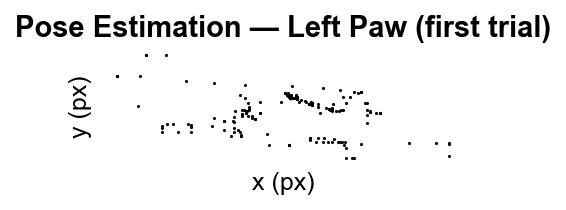

In [ ]:
if "pose_estimation" in nwbfile.processing:
    pose_series_left_paw = left_camera.pose_estimation_series["PoseEstimationSeriesLeftPaw"]

    data       = np.array(pose_series_left_paw.data)
    timestamps = np.array(pose_series_left_paw.timestamps)

    trial_start = nwbfile.trials["start_time"][0]
    trial_stop  = nwbfile.trials["stop_time"][0]

    mask = (timestamps >= trial_start) & (timestamps <= trial_stop)
    x, y = data[mask, 0], data[mask, 1]

    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    ax.plot(x, y, ".", markersize=1)
    ax.set_xlabel(f"x ({pose_series_left_paw.unit})")
    ax.set_ylabel(f"y ({pose_series_left_paw.unit})")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Pose Estimation — Left Paw (first trial)")
    ax.set_frame_on(False)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()